# **Task 1: Use NLP Techniques to Analyze a Collection of Texts**

## **Project Title: NLP-Based Topic Modeling of Consumer Complaints**

### **Notebook 3: Finding the Optimal Number of Topics (k)**

#### **Introduction**

Topic modeling requires selecting the optimal number of topics (k) to ensure meaningful and interpretable topic extraction. In previous studies, an arbitrary k value (e.g., 10) is often chosen, but this may not be the best representation of the dataset. 

This notebook systematically determines the optimal k by evaluating coherence scores across different topic numbers for LDA and NMF models.

Unlike LDA and NMF, BERTopic dynamically determines the optimal number of topics using "nr_topics='auto'", which reduces redundant topics automatically. Therefore, BERTopic is not included in this step and will be handled directly in the training and evaluation phase.

## **1. Import Necessary Libraries**

In [1]:
# Basic
import pandas as pd
import numpy as np
import spacy
import nltk

# Modeling
from gensim.models.ldamodel import LdaModel
from gensim.corpora.dictionary import Dictionary
from sklearn.decomposition import NMF

# Evaluation and Visualization
from gensim.models import CoherenceModel
import matplotlib.pyplot as plt

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

## **2. Load Preprocessed and  Vectorized Data**

In [2]:
# Define the file path
file_path = "/Users/achshahrm/Library/Mobile Documents/com~apple~CloudDocs/Documents/IU International/Sem 05/Project Data Analysis/project_final/data/preprocessed_complaints.csv"

# Load the data into a DataFrame
data_preprocessed = pd.read_csv(file_path)

# Display the first few rows of the DataFrame
data_preprocessed.head()

,complaints_text
0,purchase order day shipping amount receive pro...
1,forward message date tue subject please invest...
2,forward message cc send friday pdt subject fin...
3,payment history miss credit report specialize ...
4,payment history miss credit report make mistak...


In [12]:
# Load BoW and TF-IDF feature names
feature_names_bow = np.loadtxt("/Users/achshahrm/Library/Mobile Documents/com~apple~CloudDocs/Documents/IU International/Sem 05/Project Data Analysis/project_final/results/vectorized/feature_names_bow.txt", dtype=str)
feature_names_tfidf = np.loadtxt("/Users/achshahrm/Library/Mobile Documents/com~apple~CloudDocs/Documents/IU International/Sem 05/Project Data Analysis/project_final/results/vectorized/feature_names_tfidf.txt", dtype=str)

# Define the file path
bow_path = "/Users/achshahrm/Library/Mobile Documents/com~apple~CloudDocs/Documents/IU International/Sem 05/Project Data Analysis/project_final/results/vectorized/bow_representation.csv"
tfidf_path = "/Users/achshahrm/Library/Mobile Documents/com~apple~CloudDocs/Documents/IU International/Sem 05/Project Data Analysis/project/results/vectorized/tfidf_representation.csv"

# Load the data into a DataFrame
bow_df = pd.read_csv(bow_path)
tfidf_df = pd.read_csv(tfidf_path)

In [4]:
# Display the first few rows of the BoW DataFrame
bow_df.head()

,aa,aadvantage,aag,aargon,abandon,abide,ability,able,abroad,abruptly,...,yo,york,young,yr,zelle,zero,zip,zombie,zone,zwicker
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# Display the first few rows of the TF-IDF DataFrame
tfidf_df.head()

,aa,aadvantage,aag,aargon,abandon,abide,ability,able,abroad,abruptly,...,yo,york,young,yr,zelle,zero,zip,zombie,zone,zwicker
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0968,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.105765,0.0,0.0,...,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.117352,0.0,0.0,...,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## **3. Range of topic numbers to evaluate**

In [6]:
# Testing k from 5 to 30 with a step of 6
topic_range = range(5, 31, 5) 

## **4. Latent Dirichlet Allocation (Finding Optimal k)**

In [7]:
# Tokenize the text data
tokenized_texts = data_preprocessed['complaints_text'].str.split()

# Create Dictionary and Corpus for BoW
bow_dictionary = Dictionary(tokenized_texts)
bow_corpus = [bow_dictionary.doc2bow(text) for text in tokenized_texts]

# Create Dictionary and Corpus for TF-IDF
tfidf_dictionary = Dictionary(tokenized_texts)
tfidf_corpus = [tfidf_dictionary.doc2bow(text) for text in tokenized_texts]

# Store coherence scores
coherence_scores_lda_bow = []
coherence_scores_lda_tfidf = []

for k in topic_range:
    # Train LDA with BoW
    lda_bow = LdaModel(corpus=bow_corpus, id2word=bow_dictionary, num_topics=k, random_state=42, passes=10)
    coherence_model_bow = CoherenceModel(model=lda_bow, texts=data_preprocessed['complaints_text'].str.split(),
                                         dictionary=bow_dictionary, coherence='c_v')
    coherence_scores_lda_bow.append(coherence_model_bow.get_coherence())

    # Train LDA with TF-IDF
    lda_tfidf = LdaModel(corpus=tfidf_corpus, id2word=tfidf_dictionary, num_topics=k, random_state=42, passes=10)
    coherence_model_tfidf = CoherenceModel(model=lda_tfidf, texts=data_preprocessed['complaints_text'].str.split(),
                                           dictionary=tfidf_dictionary, coherence='c_v')
    coherence_scores_lda_tfidf.append(coherence_model_tfidf.get_coherence())

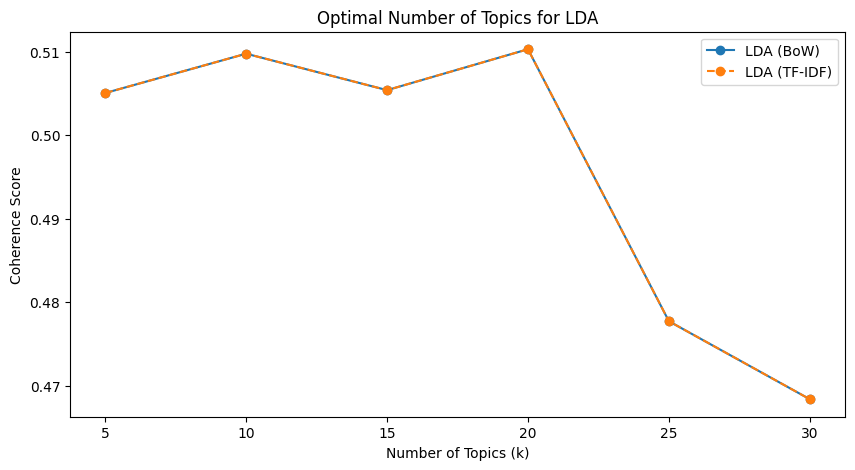

In [16]:
# Define file path to save the plot
save_path = "/Users/achshahrm/Library/Mobile Documents/com~apple~CloudDocs/Documents/IU International/Sem 05/Project Data Analysis/project_final/results/plots/lda_optimal_k.png"


# Plot coherence scores
plt.figure(figsize=(10, 5))
plt.plot(topic_range, coherence_scores_lda_bow, label="LDA (BoW)", marker="o")
plt.plot(topic_range, coherence_scores_lda_tfidf, label="LDA (TF-IDF)", marker="o", linestyle="dashed")
plt.xlabel("Number of Topics (k)")
plt.ylabel("Coherence Score")
plt.title("Optimal Number of Topics for LDA")
plt.legend()

# Save the plot
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

## **5. Non-Negative Matrix Factorization (Finding Optimal k)**

In [14]:
# Tokenize the text data
tokenized_texts = data_preprocessed['complaints_text'].str.split()

# Create Dictionary
dictionary = Dictionary(tokenized_texts)

# Function to compute coherence for NMF topics
def compute_nmf_coherence(nmf_model, feature_names, texts, dictionary, coherence='c_v'):
    # Extract top words for each topic
    topics = []
    for topic_idx in range(nmf_model.n_components):
        top_words = [feature_names[i] for i in nmf_model.components_[topic_idx].argsort()[:-11:-1]]
        topics.append(top_words)
    
    # Use Gensim's CoherenceModel
    coherence_model = CoherenceModel(topics=topics, texts=texts, dictionary=dictionary, coherence=coherence)
    coherence_score = coherence_model.get_coherence()
    
    return coherence_score


# Store coherence scores
coherence_scores_nmf_bow = []
coherence_scores_nmf_tfidf = []

for k in topic_range:
    # Train NMF with BoW
    nmf_bow = NMF(n_components=k, random_state=42, max_iter=500)
    nmf_bow_topics = nmf_bow.fit_transform(bow_df)

    # Compute Coherence Score for BoW
    coherence_nmf_bow = compute_nmf_coherence(nmf_bow, feature_names_bow, tokenized_texts, dictionary)
    coherence_scores_nmf_bow.append(coherence_nmf_bow)

    # Train NMF with TF-IDF
    nmf_tfidf = NMF(n_components=k, random_state=42, max_iter=500)
    nmf_tfidf_topics = nmf_tfidf.fit_transform(tfidf_df)

    # Compute Coherence Score for TF-IDF
    coherence_nmf_tfidf = compute_nmf_coherence(nmf_tfidf, feature_names_tfidf, tokenized_texts, dictionary)
    coherence_scores_nmf_tfidf.append(coherence_nmf_tfidf)

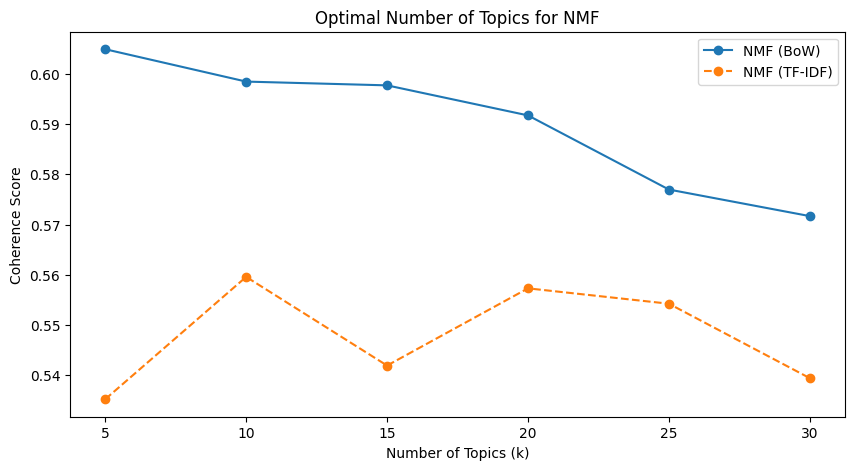

In [17]:
# Define file path to save the plot
save_path = "/Users/achshahrm/Library/Mobile Documents/com~apple~CloudDocs/Documents/IU International/Sem 05/Project Data Analysis/project_final/results/plots/nmf_optimal_k.png"

# Plot coherence scores
plt.figure(figsize=(10, 5))
plt.plot(topic_range, coherence_scores_nmf_bow, label="NMF (BoW)", marker="o")
plt.plot(topic_range, coherence_scores_nmf_tfidf, label="NMF (TF-IDF)", marker="o", linestyle="dashed")
plt.xlabel("Number of Topics (k)")
plt.ylabel("Coherence Score")
plt.title("Optimal Number of Topics for NMF")
plt.legend()

# Save the plot
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

## **Optimal Number of Topics (k) Analysis**

**LDA (Latent Dirichlet Allocation)**

From the LDA optimal k plot, coherence scores for both BoW and TF-IDF peak around k = 20 before experiencing a steep decline. This suggests that 20 topics may be the most interpretable and meaningful number for LDA before coherence decreases significantly.

**NMF (Non-Negative Matrix Factorization)**

In the NMF optimal k plot, BoW coherence scores are highest around k = 5, with a gradual decrease afterward. For TF-IDF, coherence fluctuates slightly but appears more stable around k = 10 and k = 20.

## **Next Steps**
Now that we have identified the best k for each model, the next step is to train the final models using the optimal k and evaluate the topic distributions and insights.